In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split,StratifiedKFold,GridSearchCV,LeaveOneGroupOut,cross_val_predict,cross_validate
from sklearn.metrics import (roc_auc_score,accuracy_score,precision_score,recall_score,f1_score,average_precision_score,
                             brier_score_loss,precision_recall_curve,roc_curve,confusion_matrix,classification_report,ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer,MissingIndicator
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from scipy import stats
import shap,os

RAW=Path('data/raw/heart+disease')

RANDOM_SEED=42
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_SEED)
MAX_ITER=5000

In [37]:
datapath=Path.cwd().parent / RAW

In [38]:
COLS = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach',
        'exang','oldpeak','slope','ca','thal','num']

FILES = {'cleveland'  : 'processed.cleveland.data',
         'hungary'    : 'processed.hungarian.data',
         'switzerland': 'processed.switzerland.data',
         'va'         : 'processed.va.data'}

frames=[]

for k,v in FILES.items():
    data=pd.read_csv(os.path.join(datapath,v),names=COLS,na_values='?')
    data['site']=k
    frames.append(data)

df=pd.concat(frames,ignore_index=True)
print(df.shape)
df['site'].value_counts(normalize=True).round(2)

(920, 15)


site
cleveland      0.33
hungary        0.32
va             0.22
switzerland    0.13
Name: proportion, dtype: float64

In [39]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    float64
 1   sex       920 non-null    float64
 2   cp        920 non-null    float64
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    float64
 6   restecg   918 non-null    float64
 7   thalach   865 non-null    float64
 8   exang     865 non-null    float64
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  num       920 non-null    int64  
 14  site      920 non-null    str    
dtypes: float64(13), int64(1), str(1)
memory usage: 114.4 KB


In [40]:
def bin_values(df,id_thresh=0.95,cat_thresh=5,force_cat=None,datetime_cols=None):
    n=len(df)
    buckets={'id':[],'datetime':[],'categorical':[],'dis_num':[],'cont':[],'binary':[]}
    datetime_cols=set(datetime_cols or [])
    force_cat=set(force_cat or [])

    for col in df.columns:
        if col == 'site':continue
        
        s=df[col]
        nunique=s.nunique()

        if pd.api.types.is_datetime64_any_dtype(s) or col in datetime_cols:
            buckets['datetime'].append(col)
            continue
        is_id_like_dtype=pd.api.types.is_integer_dtype(s) or pd.api.types.is_numeric_dtype(s)
        if is_id_like_dtype and n>=0 and nunique/n>id_thresh:
            buckets['id'].append(col)
            continue
        if col in force_cat:
            buckets['categorical'].append(col)
            continue
        if nunique==2:
            buckets['binary'].append(col)
            continue
        if pd.api.types.is_numeric_dtype(s) and nunique >cat_thresh:
            buckets['cont'].append(col)
            continue
        else:
            buckets['categorical'].append(col)
    return buckets

buckets=bin_values(df)
buckets




{'id': [],
 'datetime': [],
 'categorical': ['cp', 'restecg', 'slope', 'ca', 'thal', 'num'],
 'dis_num': [],
 'cont': ['age', 'trestbps', 'chol', 'thalach', 'oldpeak'],
 'binary': ['sex', 'fbs', 'exang']}

In [41]:
df.describe()[buckets['cont']].T

,count,mean,std,min,25%,50%,75%,max
age,920.0,53.510870,9.424685,28.0,47.0,54.0,60.0,77.0
trestbps,861.0,132.132404,19.066070,0.0,120.0,130.0,140.0,200.0
chol,890.0,199.130337,110.780810,0.0,175.0,223.0,268.0,603.0
thalach,865.0,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.0,0.5,1.5,6.2


In [42]:
#senitel value check
for c in buckets['cont']:
    print(c,(df[c]==0).sum(),(df[c]<0).sum(),(df[c] > df[c].quantile(.999)*3).sum())

age 0 0 0
trestbps 1 0 0
chol 172 0 0
thalach 0 0 0
oldpeak 370 12 0


In [43]:
df['num'].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

0 for chol and trestbps are not physically not possible.

In [44]:
for c in ['chol','trestbps']:
    n=(df[c]==0).sum()
    df.loc[(df[c]==0),c]=np.nan
    print(f' changed {n} values -> Nan in {c}')

#binarizing the target 
df['target']=(df['num']>0).astype(int)
df=df.drop(columns='num')

print(f'prevalance {df['target'].mean():.2f}')
df['target'].value_counts()

 changed 172 values -> Nan in chol
 changed 1 values -> Nan in trestbps
prevalance 0.55


target
1    509
0    411
Name: count, dtype: int64

In [45]:
def audit(df):
    return pd.DataFrame({
        'null values':df.isnull().sum(),
        'null_%':df.isnull().mean()*100,
        'unique':df.nunique(),
        'unique_%':(df.nunique()/len(df)*100),
        'dtype':df.dtypes.astype(str),
        'zero':(df==0).sum(),
        'top_value':df.mode().iloc[0],
        'top_freq_%':((df.apply(lambda g:g.value_counts(normalize=True).iloc[0]))*100),
        'sample':df.iloc[0]
    })
audit(df).round(3)

,null values,null_%,unique,unique_%,dtype,zero,top_value,top_freq_%,sample
age,0,0.000,50,5.435,float64,0,54.0,5.543,63.0
sex,0,0.000,2,0.217,float64,194,1.0,78.913,1.0
cp,0,0.000,4,0.435,float64,0,4.0,53.913,1.0
trestbps,60,6.522,60,6.522,float64,0,120.0,15.233,145.0
chol,202,21.957,216,23.478,float64,0,220.0,1.393,233.0
fbs,90,9.783,2,0.217,float64,692,0.0,83.373,1.0
restecg,2,0.217,3,0.326,float64,551,0.0,60.022,2.0
thalach,55,5.978,119,12.935,float64,0,150.0,4.971,150.0
exang,55,5.978,2,0.217,float64,528,0.0,61.040,0.0
oldpeak,62,6.739,53,5.761,float64,370,0.0,43.124,2.3


In [46]:
#MCAR MNAR MAR
missing_values=df.groupby('site').apply(lambda g: g.isna().mean()*100,include_groups=False)
missing_values.loc[:,(missing_values.max()>0)].round(3)

,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
site,,,,,,,,,,
cleveland,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.320,0.660
hungary,0.340,7.823,2.721,0.340,0.340,0.340,0.000,64.626,98.980,90.476
switzerland,1.626,100.000,60.976,0.813,0.813,0.813,4.878,13.821,95.935,42.276
va,28.500,28.000,3.500,0.000,26.500,26.500,28.000,51.000,99.000,83.000


In [47]:
pd.crosstab(df['site'],df['target'],normalize='index')

target,0,1
site,,
cleveland,0.541254,0.458746
hungary,0.639456,0.360544
switzerland,0.065041,0.934959
va,0.255000,0.745000


reading above tables side by side , for 
clv: balance data , full clinical workup,  more general population 
swt: very high prev, most likely only the diseased were included in the trials . and chol is fully missing , ca ~ 95 
va: moderate missing across board, ca heavily missing . prev suggests same case as swt , only less extreme.
hung: slope ca, thal almost missing entirely , but others are relatively complete. prev is lowest. missingness doesnt track prev the way swt does.

**key takeaways**
missingness and prev vary strongly by site. in case of swz and va they move together
so missingness is not at random,so a column like ca being missing might itself be info about site.
`if we build ' is this missing ' indicator then that may just be end up being proxy for site. the model could just learn 'missing> prob singapore > probably diseased' , whihc is not good for generalisation `

so argument for checking performance isnt driven by one or 2 sites, and using stratified train test split by site.



In [48]:
df[df.duplicated(keep=False)]
df=df.drop_duplicates(keep='first')
df.duplicated().sum()
df.shape


(918, 15)

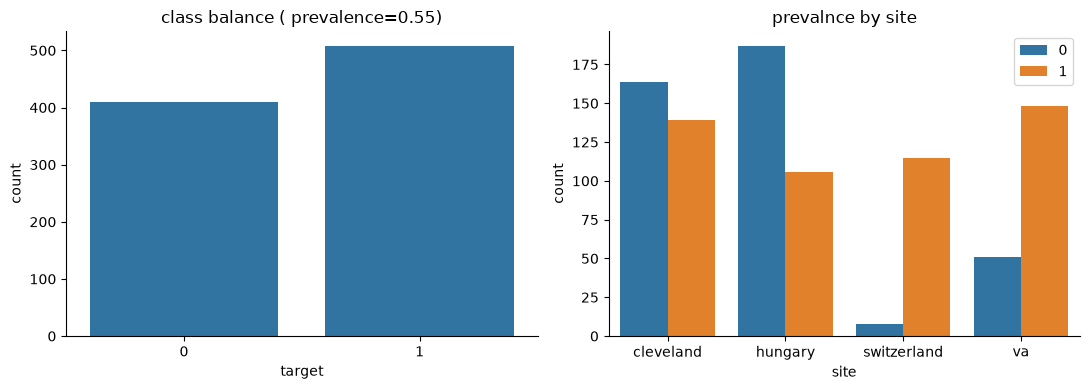

In [49]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
sns.countplot(df,x='target',ax=axes[0])
axes[0].set_title(f'class balance ( prevalence={df['target'].mean():.2f})')
sns.countplot(df,x='site',hue='target',ax=axes[1])
axes[1].set_title('prevalnce by site')
plt.legend(loc='best')
plt.tight_layout()
sns.despine(top=True,right=True)

<Axes: xlabel='target', ylabel='count'>

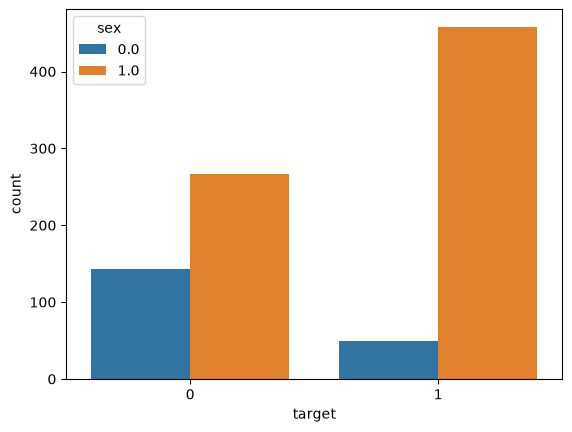

In [50]:
sns.countplot(df,x='target',hue='sex')

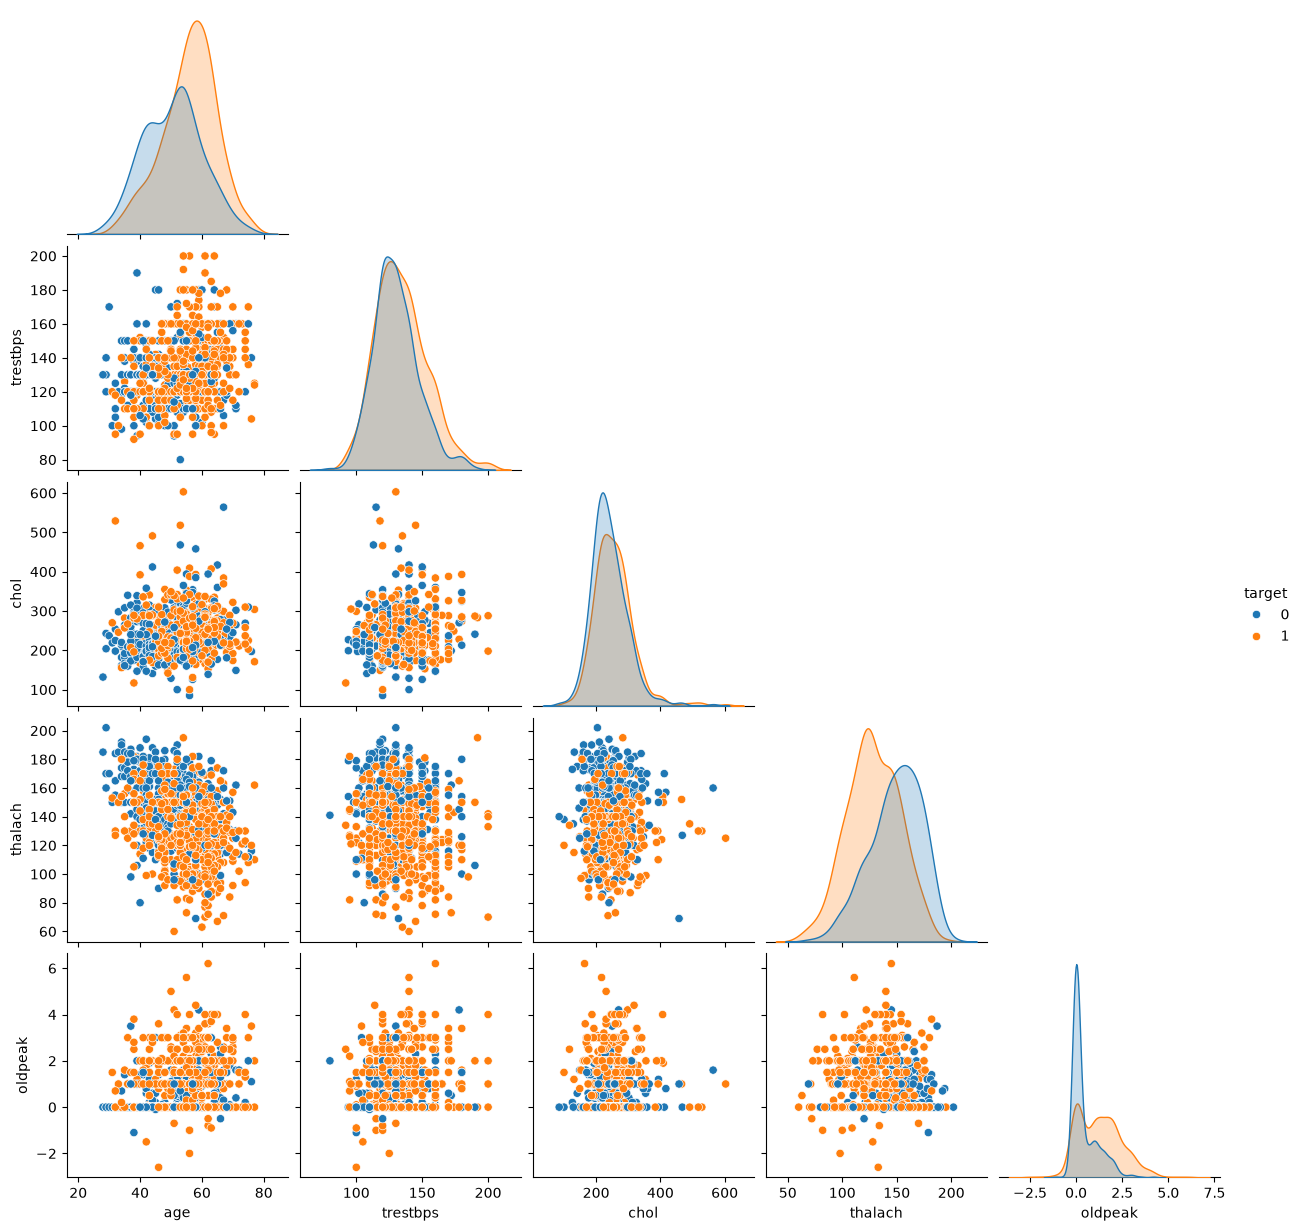

In [51]:
df_pairplot=df[buckets['cont']+['target']]
sns.pairplot(df_pairplot,kind='scatter',hue='target',corner=True)


thalach  is the strongest single separator. The orange peak sits near 125 and the blue near 155 with only partial overlap.
age vs thalach: the cloud slopes downward because max heart rate falls with age and  orange sits below blue at same age.pair separates the classes better than either alone.

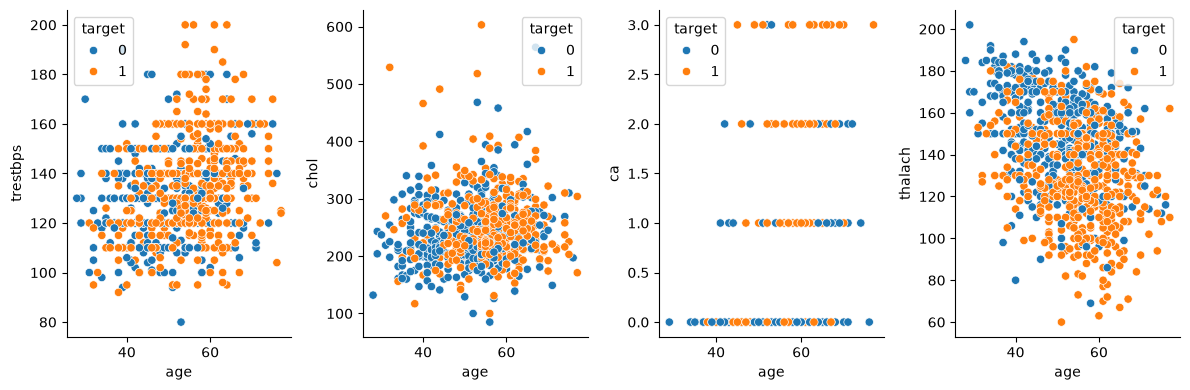

In [52]:
fig,axes=plt.subplots(1,4,figsize=(12,4))
sns.scatterplot(data=df,x='age',y='trestbps',hue='target',ax=axes[0])
sns.scatterplot(data=df,x='age',y='chol',hue='target',ax=axes[1])
sns.scatterplot(data=df,x='age',y='ca',hue='target',ax=axes[2])
sns.scatterplot(data=df,x='age',y='thalach',hue='target',ax=axes[3])
[ax.spines[['top','right']].set_visible(False) for ax in fig.axes]
fig.tight_layout()

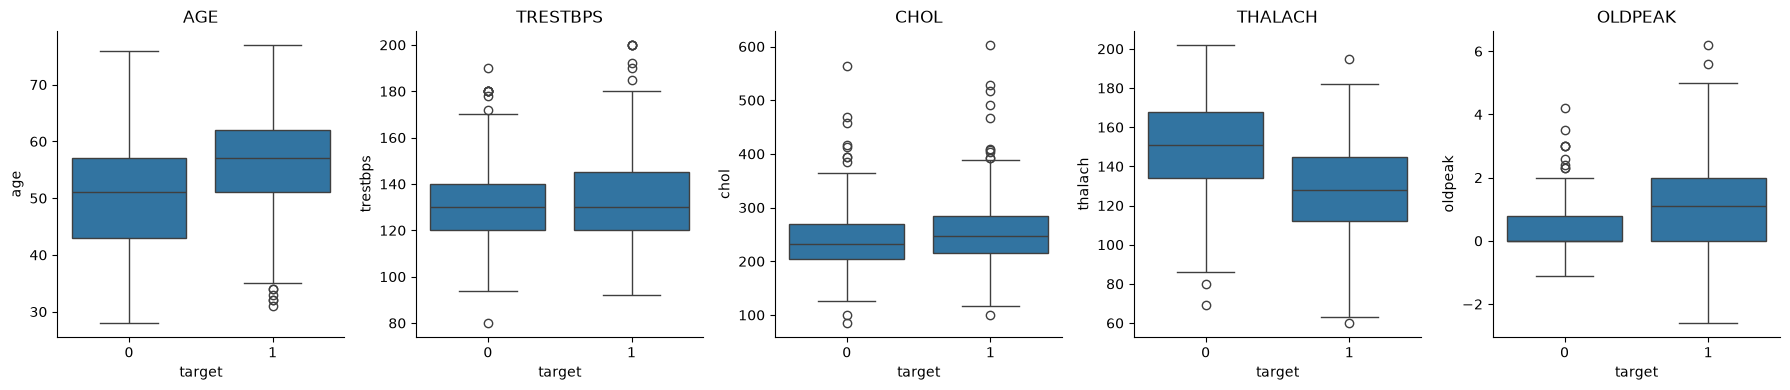

In [53]:
fig,axes=plt.subplots(1,len(buckets['cont']),figsize=(18,4))
for ax, col in zip(axes,buckets['cont']):
    sns.boxplot(df,x='target',y=col,patch_artist=True,ax=ax)
    ax.set_title(col.upper())
[ax.spines[['top','right']].set_visible(False) for ax in fig.axes]
plt.tight_layout()

<Axes: >

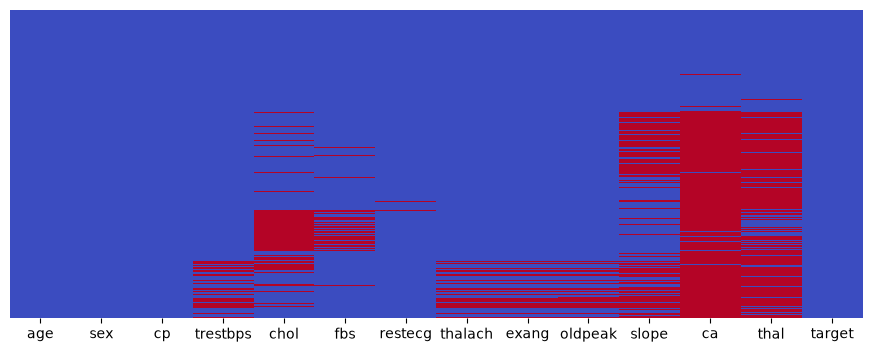

In [54]:
#missing map
plt.figure(figsize=(11,4))
sns.heatmap(df.sort_values('site').drop(columns='site').isna(),cmap='coolwarm',yticklabels=False,cbar=False)

<Axes: >

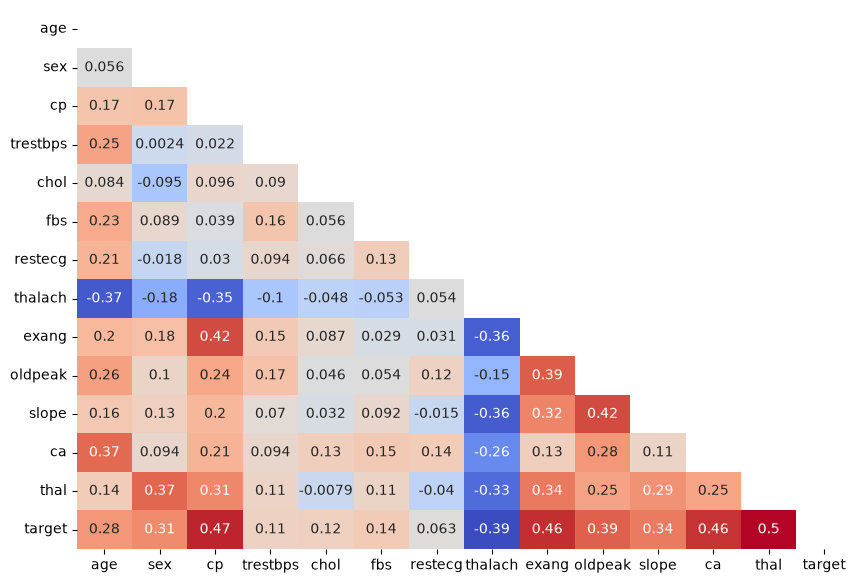

In [55]:
plt.figure(figsize=(10,7))
corr=df.drop('site',axis=1).corr()
mask=np.triu(np.ones_like(corr))
sns.heatmap(corr,mask=mask,annot=True,cmap='coolwarm',cbar=False)

In [56]:
(df['exang'].isna()==df['thalach'].isna()).mean()

np.float64(1.0)

binning based on cardinality doesnt tell us nominal/ordinal . overriding those .

In [57]:
df.exang.value_counts()

exang
0.0    527
1.0    336
Name: count, dtype: int64

In [58]:
DROP_HIGH_MISS=True
INCLUDE_SITE=False
drop_thresh=0.3
ROLES = {
    'cont'   : ['age', 'trestbps', 'chol', 'thalach', 'oldpeak'],
    'binary' : ['sex', 'fbs'],
    'nominal': ['cp', 'restecg', 'thal','exang'], #exang is in this instead of binary values to avoid missing indic
    'ordinal': ['slope', 'ca'],
}
high_miss= [v for v in sum(ROLES.values(),[]) if df[v].isna().mean()>drop_thresh]
print(f'Dropped {str(high_miss):>34}')

if DROP_HIGH_MISS:
    ROLES={k: [c for c in v if c not in high_miss]for k,v in ROLES.items()}

CONT=ROLES['cont']
BINARY=ROLES['binary']
NUMERIC=CONT+ROLES['ordinal']
CATEGORICAL=ROLES['nominal']+ (['site'] if INCLUDE_SITE else [])

FEATURES=NUMERIC+BINARY+CATEGORICAL
print(f'Numeric {str(NUMERIC):>60}'
      f'\nBinary {str(BINARY):>26}'
      f'\nCategorical {str(CATEGORICAL):>33}')

X=df[FEATURES].copy()
y=df['target'].copy()

groups=df['site'].copy()

assert X.shape[0]==y.size
X.shape


Dropped            ['thal', 'slope', 'ca']
Numeric            ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Binary             ['sex', 'fbs']
Categorical        ['cp', 'restecg', 'exang']


(918, 10)

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,stratify=y, random_state=42)

g_train=groups.loc[X_train.index]
print(f'design matrix train {X_train.shape} \ndesign matrix test {X_test.shape}'
      f'\ntrain prevalance {y_train.mean():.3f} test prevalance {y_test.mean():.3f}')

design matrix train (688, 10) 
design matrix test (230, 10)
train prevalance 0.554 test prevalance 0.552


since we have missing values , lets see if indicator has nay leakage 

In [60]:
ind_audit=[]
for c in X_train.columns:
    m=X_train[c].isna().astype(int)
    if m.sum() and m.sum() < len(m):
        ind_audit.append({
            'column':c,
            'missing_pct':X_train[c].isna().mean()*100,
            'auc_Indicator':round(roc_auc_score(y_train,m),2) #for positive class for negative 1-auc
        })
pd.DataFrame(ind_audit).sort_values('auc_Indicator',ascending=False)

,column,missing_pct,auc_Indicator
1,chol,21.656977,0.60
4,fbs,9.156977,0.55
0,trestbps,6.976744,0.52
2,thalach,6.540698,0.51
3,oldpeak,7.122093,0.51
5,exang,6.540698,0.51


auc indicator >0.5 may cause leakage . chol is one example.thalach and exang come from same test . skipping missing indiacator  for categorical

In [61]:
num_pipeline=Pipeline([('imputer',SimpleImputer(strategy='median')),
                       ('scalar',StandardScaler())])
binary_pipleine=Pipeline([('impute',SimpleImputer(strategy='most_frequent'))])
nominal_pipeline=Pipeline([('impute',SimpleImputer(strategy='most_frequent')),
                           ('ohe',OneHotEncoder(drop='first',handle_unknown='infrequent_if_exist',sparse_output=False))])

preprocessor=ColumnTransformer([('num',num_pipeline,NUMERIC),
                                ('bin',binary_pipleine,BINARY),
                                ('nom',nominal_pipeline,CATEGORICAL),
                                # ('missing',MissingIndicator(features='missing-only'),NUMERIC+BINARY)],remainder='passthrough')
                                ('missing', MissingIndicator(features='all'), ['trestbps', 'thalach', 'oldpeak'])],remainder='passthrough') #fix, add check before predict TODO
preprocessor.fit(X_train,y_train)
feature_names= [n.split('__',1)[1] for n in preprocessor.get_feature_names_out()]
feature_names,len(feature_names)


(['age',
  'trestbps',
  'chol',
  'thalach',
  'oldpeak',
  'sex',
  'fbs',
  'cp_2.0',
  'cp_3.0',
  'cp_4.0',
  'restecg_1.0',
  'restecg_2.0',
  'exang_1.0',
  'missingindicator_trestbps',
  'missingindicator_thalach',
  'missingindicator_oldpeak'],
 16)

Missing-indicator limitation

MissingIndicator(features='missing-only') is fed NUMERIC+BINARY.:
Flags are frozen at fit time. Only columns with NaN in X_train get a flag (currently trestbps, chol, thalach, oldpeak, fbs). Columns that were complete in training (age, sex) get none.
 It fails loudly on new NaN. With error_on_new=True (the default), a NaN in age or sex at predict time raises a ValueError, even though the imputers could have filled it. This works as a crude guard, not a designed input check.


 fix: features='all' on an explicit list (trestbps, thalach, oldpeak) plus an input check before predict.TODO. done

In [62]:
preprocessor['missing'].features_,NUMERIC+BINARY

(array([0, 1, 2]),
 ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'fbs'])

In [63]:
Z_train=pd.DataFrame(preprocessor.transform(X_train),columns=feature_names,index=X_train.index)
keep=Z_train.columns[Z_train.std()>1e-8]
dropped=set(Z_train.columns)-set(keep)
if dropped:
    print(f'dropping zero variance columns {dropped}')
Z_train=Z_train[keep]

Zc=sm.add_constant(Z_train,has_constant='add')
vif=pd.DataFrame({
    'features':Zc.columns,
    'vif': [variance_inflation_factor(Zc.values,c) for c in range(Zc.shape[1])]
})
vif[vif.features != 'const'].sort_values('vif',ascending=False)


,features,vif
15,missingindicator_thalach,18.416867
14,missingindicator_trestbps,16.031775
16,missingindicator_oldpeak,8.272292
10,cp_4.0,6.245865
9,cp_3.0,4.520518
8,cp_2.0,4.275781
13,exang_1.0,1.522873
4,thalach,1.455066
1,age,1.403508
5,oldpeak,1.291171


missing indicators having vif >10 are all from VA , prediction model will be fine( only sum matters for it) as it will regularised. but stats model inference will be broken. SE will be inflated , Ci will be too wide   , p values will become un intrepretable as it will be large even if the block matters . lets collapse them into 1

In [64]:
va_battery_cols = ['missingindicator_trestbps', 'missingindicator_thalach', 'missingindicator_oldpeak']

Z_train_inf = Z_train.copy()
Z_train_inf['missingindicator_va_battery'] = Z_train_inf[va_battery_cols].max(axis=1)
Z_train_inf = Z_train_inf.drop(columns=va_battery_cols)

Zc_inf = sm.add_constant(Z_train_inf, has_constant='add')
vif_inf = pd.DataFrame({
    'features': Zc_inf.columns,
    'vif': [variance_inflation_factor(Zc_inf.values, c) for c in range(Zc_inf.shape[1])]
})
vif_inf[vif_inf.features != 'const'].sort_values('vif', ascending=False)


,features,vif
10,cp_4.0,6.245656
9,cp_3.0,4.521031
8,cp_2.0,4.274050
13,exang_1.0,1.519769
4,thalach,1.447764
1,age,1.392974
5,oldpeak,1.281661
11,restecg_1.0,1.201036
14,missingindicator_va_battery,1.195806
12,restecg_2.0,1.168239


now multicollinearity seems ok

In [65]:
r,k =np.linalg.matrix_rank(Zc),Zc.shape[1]
assert r==k #verifying no  identifiability 

In [66]:
#dummy baseline
def evaluate(y_true,p_hat,thresh=0.5,name='',split=''):
    y_pred=(p_hat >= thresh).astype(int)
    return {'model':name,'split':split,'threshold':round(thresh,3),
            'accuracy':round(accuracy_score(y_true,y_pred),3),
            'precision':round(precision_score(y_true,y_pred,zero_division=0),3),
            'recall':round(recall_score(y_true,y_pred,zero_division=0),3),
            'f1_score':round(f1_score(y_true,y_pred,zero_division=0),3),
            'roc_auc':round(roc_auc_score(y_true,p_hat),3),
            'avg_precision':round(average_precision_score(y_true,p_hat),3),
            'brier':round(brier_score_loss(y_true,p_hat),3)}

rows=[]

for strat in ['prior','most_frequent','stratified']:
    dm=DummyClassifier(strategy=strat,random_state=RANDOM_SEED).fit(X_train,y_train)
    rows.append(evaluate(y_train,dm.predict_proba(X_train)[:,1],name=f'dummy {strat}',split='train'))

pd.DataFrame(rows)



,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,avg_precision,brier
0,dummy prior,train,0.5,0.554,0.554,1.000,0.713,0.500,0.554,0.247
1,dummy most_frequent,train,0.5,0.554,0.554,1.000,0.713,0.500,0.554,0.446
2,dummy stratified,train,0.5,0.510,0.558,0.559,0.558,0.504,0.556,0.490


ap equals prevalence for prior / most freq. textbook baseline.and prior and most freq only differe in prob they emit which is why only the brier is different. 
for prior predict_proba returns the class proportions themselves, $0.553$ for positive and $0.447$ for negative, for every row. for mf predict_proba returns a hard 0/1 vector, probability 1 for the majority class and 0 for the other.
strat used to get baseline for the imbalanced ( not exactly the case here ) metric 

In [67]:
base_logreg=Pipeline([('pre',preprocessor),
                      ('baselogReg',LogisticRegression(max_iter=MAX_ITER,random_state=RANDOM_SEED))]).fit(X_train,y_train)

rows.append(evaluate(y_train,base_logreg.predict_proba(X_train)[:,1],name='base log reg',split='train'))
pd.DataFrame(rows)

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,avg_precision,brier
0,dummy prior,train,0.5,0.554,0.554,1.000,0.713,0.500,0.554,0.247
1,dummy most_frequent,train,0.5,0.554,0.554,1.000,0.713,0.500,0.554,0.446
2,dummy stratified,train,0.5,0.510,0.558,0.559,0.558,0.504,0.556,0.490
3,base log reg,train,0.5,0.815,0.819,0.856,0.837,0.881,0.888,0.137


In [68]:
pipe=Pipeline([
    ('pre',preprocessor),
    ('clf',LogisticRegression(penalty='elasticnet',solver='saga',
                              max_iter=4*MAX_ITER,random_state=RANDOM_SEED))])
params_grid={'clf__C' :np.logspace(-5,2,15),
             'clf__l1_ratio':[0.0,.25,.5,.75,1.0]}

gs=GridSearchCV(pipe,params_grid,scoring={'log_loss':'neg_log_loss','auc':'roc_auc'},cv=cv,n_jobs=-1,return_train_score=True,refit='log_loss')
gs.fit(X_train,y_train)
print(f' best params :{gs.best_params_}')
print(f' best score : {-gs.best_score_}')


/home/risha/.venvs/heart-disease/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/risha/.venvs/heart-disease/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/risha/.venvs/hea

 best params :{'clf__C': np.float64(0.31622776601683794), 'clf__l1_ratio': 0.0}
 best score : 0.450242857837764


/home/risha/.venvs/heart-disease/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [69]:
res=pd.DataFrame(gs.cv_results_)
res.columns
cols=['mean_train_auc','mean_test_auc', 'std_test_auc','mean_train_log_loss','mean_test_log_loss', 'std_test_log_loss',
      'param_clf__C','param_clf__l1_ratio']
res=res[cols].copy()
res['gap log loss']=res['mean_train_log_loss']-res['mean_test_log_loss']
res['gap_auc']=res['mean_train_auc']-res['mean_test_auc']
res.sort_values('param_clf__C')[['param_clf__l1_ratio','gap log loss','gap_auc']]
aa=res.pivot_table(index='param_clf__C',columns='param_clf__l1_ratio', values=['gap log loss','gap_auc'], aggfunc='mean')
# res.groupby(['param_clf__l1_ratio','param_clf__C'])[['gap log loss','gap_auc']].mean()
aa.columns= [f"{i}_l1 penalty{j}" for i,j in aa.columns]
aa

,gap log loss_l1 penalty0.0,gap log loss_l1 penalty0.25,gap log loss_l1 penalty0.5,gap log loss_l1 penalty0.75,gap log loss_l1 penalty1.0,gap_auc_l1 penalty0.0,gap_auc_l1 penalty0.25,gap_auc_l1 penalty0.5,gap_auc_l1 penalty0.75,gap_auc_l1 penalty1.0
param_clf__C,,,,,,,,,,
0.000010,0.000019,-0.000016,-0.000016,-0.000007,0.000067,0.005154,0.000000,0.000000,0.000000,0.000000
0.000032,0.000042,-0.000006,0.000007,0.000033,0.000067,0.005224,0.000000,0.000000,0.000000,0.000000
0.000100,0.000111,0.000035,0.000047,0.000058,0.000067,0.005513,0.000000,0.000000,0.000000,0.000000
0.000316,0.000319,0.000069,0.000062,0.000064,0.000067,0.005472,0.000000,0.000000,0.000000,0.000000
0.001000,0.000892,0.000048,0.000075,0.000076,0.000067,0.005822,0.000000,0.000000,0.000000,0.000000
0.003162,0.002256,0.000439,0.000049,0.000105,0.000056,0.005395,0.000177,0.000000,0.000000,0.000000
0.010000,0.005023,0.003075,0.001628,0.000816,0.000537,0.006638,0.005186,0.003695,0.000116,0.000345
0.031623,0.009620,0.007686,0.007634,0.005742,0.003393,0.008777,0.006693,0.006296,0.005714,0.003164
0.100000,0.015392,0.014235,0.012482,0.012926,0.014400,0.011525,0.010785,0.009098,0.010029,0.011528


c is not pinned to boundaries, so our range was ok.  gap grows continuously, steepest between C=0.01–1, and our chosen C sits inside that growth region, not before it

In [70]:
nested = cross_validate(
    gs, X_train, y_train, cv=cv,
    scoring={'log_loss': 'neg_log_loss', 'auc': 'roc_auc', 'ap': 'average_precision'},
    return_estimator=True,n_jobs=-1
)


/home/risha/.venvs/heart-disease/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/risha/.venvs/heart-disease/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/risha/.venvs/hea

In [71]:
nested.keys()
pd.DataFrame({k: -nested[k] if 'log' in k else nested[k] for k in ['test_log_loss', 'test_auc', 'test_ap']})



,test_log_loss,test_auc,test_ap
0,0.465016,0.859720,0.872305
1,0.399055,0.899194,0.914501
2,0.474218,0.852885,0.853126
3,0.481823,0.846851,0.883369
4,0.434092,0.880069,0.878730


good news that our cv log loss is close to values here


In [72]:
[e.best_params_ for e in nested['estimator']]

[{'clf__C': np.float64(0.31622776601683794), 'clf__l1_ratio': 0.5},
 {'clf__C': np.float64(0.31622776601683794), 'clf__l1_ratio': 0.0},
 {'clf__C': np.float64(0.31622776601683794), 'clf__l1_ratio': 0.5},
 {'clf__C': np.float64(0.31622776601683794), 'clf__l1_ratio': 0.0},
 {'clf__C': np.float64(0.31622776601683794), 'clf__l1_ratio': 0.75}]

C = 0.316 was selected in all 5 outer folds. l1_ratio varied (0.0, 0.5, 0.75),so the L1/L2 mix is not pinned down, but test loss is nearly flat along it and the nested score is unaffected.

In [73]:


scores = pd.DataFrame({
    'log_loss': -nested['test_log_loss'],
    'auc': nested['test_auc'],
    'ap': nested['test_ap']
})
summary = scores.agg(['mean', 'std'])
print(summary)

single_split = -gs.best_score_
nested_mean = summary.loc['mean', 'log_loss']
nested_std = summary.loc['std', 'log_loss']

print(f"\nsingle-split (gs.best_score_): {single_split:.4f}")
print(f"nested CV: {nested_mean:.4f} ± {nested_std:.4f}")
print(f"within 1 nested std: {abs(single_split - nested_mean) <= nested_std}")


      log_loss       auc        ap
mean  0.450841  0.867744  0.880406
std   0.034167  0.021579  0.022271

single-split (gs.best_score_): 0.4502
nested CV: 0.4508 ± 0.0342
within 1 nested std: True


nested cv has confirmed that our cv score is good enough to report

In [74]:
final_model=gs.best_estimator_

coef=pd.Series(final_model.named_steps['clf'].coef_[0],index=feature_names)
# coef
print(f'non zero coefficinets: {(coef.abs()>1e-6).sum()} / {len(coef)}')
coef[coef.abs()>1e-6].sort_values(key=abs,ascending=False)

non zero coefficinets: 16 / 16


sex                          1.130534
cp_4.0                       0.992031
exang_1.0                    0.952375
cp_2.0                      -0.840149
oldpeak                      0.486444
thalach                     -0.442232
age                          0.284497
restecg_1.0                  0.283948
chol                         0.217517
missingindicator_trestbps    0.207772
cp_3.0                      -0.179597
fbs                          0.157499
missingindicator_oldpeak     0.144351
restecg_2.0                  0.137036
missingindicator_thalach     0.118202
trestbps                     0.015394
dtype: float64

In [75]:
#leave one group out cv to make sure it works for sites other than mentioned 4
logo=LeaveOneGroupOut()
# scores=cross_val_score(final_model,X,y,groups=groups,cv=logo,scoring='neg_log_loss')
# scores_auc=cross_val_score(final_model,X,y,groups=groups,cv=logo,scoring='roc_auc')

nested_scores=cross_validate(final_model,X_train,y_train,groups=g_train,cv=logo,scoring={'log_loss': 'neg_log_loss', 'auc': 'roc_auc', 'ap': 'average_precision'})
# print(dict(zip(FILES,-scores)))
# dict(zip(FILES,scores_auc))
nested_scores.keys()

/home/risha/.venvs/heart-disease/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/risha/.venvs/heart-disease/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/risha/.venvs/hea

dict_keys(['fit_time', 'score_time', 'test_log_loss', 'test_auc', 'test_ap'])

In [76]:
pd.DataFrame({ k : nested_scores[k] if 'log' not in k else - nested_scores[k]  for k in ['test_log_loss', 'test_auc', 'test_ap']},index=sorted(groups.unique()))

,test_log_loss,test_auc,test_ap
cleveland,0.492775,0.853204,0.851175
hungary,0.436860,0.892279,0.867201
switzerland,0.560320,0.731922,0.966110
va,0.530289,0.712251,0.864690


LOGO CV: cleveland 0.853 and hungary 0.892 AUC, within about 1 nested std of
the 5-fold nested mean (0.868). switzerland 0.732 and va 0.712 are well below
it, a real generalization gap and not fold noise. switzerland AP (0.966) is
mostly its 93% prevalence, so AUC is the fair read, and with very few
negatives that AUC is noisy. The drop is consistent with the model leaning on
site-linked missingness (indicator coefficients), but this is untested.
Ablation without those indicators is needed to attribute it. Headline: 5-fold
nested AUC 0.868 is a within-site estimate. Across held-out sites AUC ranged
0.71-0.89 (mean about 0.80).

In [77]:
#choosing threshold. for new site to be tuned again using LOGO OOF

cv_oof=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_SEED+1)

p_oof=cross_val_predict(final_model,X_train,y_train,cv=cv_oof,method='predict_proba')[:,1]
prec,rec,thr=precision_recall_curve(y_train,p_oof)
f1s= 2* prec * rec/(prec+rec+1e-12)
t_f1=thr[np.nanargmax(f1s[:-1])]

TARGET_RECALL=.9
ok=np.where(rec[:-1]> TARGET_RECALL)[0]
t_recall=thr[ok[np.argmax(prec[:-1][ok])]]

C_FP,C_FN=1.0,4.0 #bayes rule
t_cost=C_FP/(C_FP+C_FN)

print(f'F1-optimal      t = {t_f1:.3f}')
print(f'recall >= {TARGET_RECALL}  t = {t_recall:.3f}')
print(f'cost-optimal    t = {t_cost:.3f}  (c_FN = {C_FN/C_FP:.0f}x c_FP)')
len(p_oof)




/home/risha/.venvs/heart-disease/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/risha/.venvs/heart-disease/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/risha/.venvs/hea

F1-optimal      t = 0.412
recall >= 0.9  t = 0.382
cost-optimal    t = 0.200  (c_FN = 4x c_FP)


/home/risha/.venvs/heart-disease/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


688

In [78]:
cv_oof_newSite=cross_val_predict(final_model,X_train,y_train,cv=logo,groups=g_train,method='predict_proba')[:,1]
prec1,rec1,thres1=precision_recall_curve(y_train,cv_oof_newSite)
f1s1=2 * prec1 * rec1/(prec1+rec1+1e-12)
t_f11=thres1[np.nanargmax(f1s1[:-1])]

ok1=np.where(rec1[:-1]>TARGET_RECALL)[0]
t_recall1=thres1[ok[np.argmax(prec1[:-1][ok1])]]

print(f'{t_f11:.3f}')
print(f'{t_recall1:.3f}')

/home/risha/.venvs/heart-disease/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/risha/.venvs/heart-disease/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/risha/.venvs/heart-disease/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/risha/.venvs/heart-disease/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


0.348
0.397


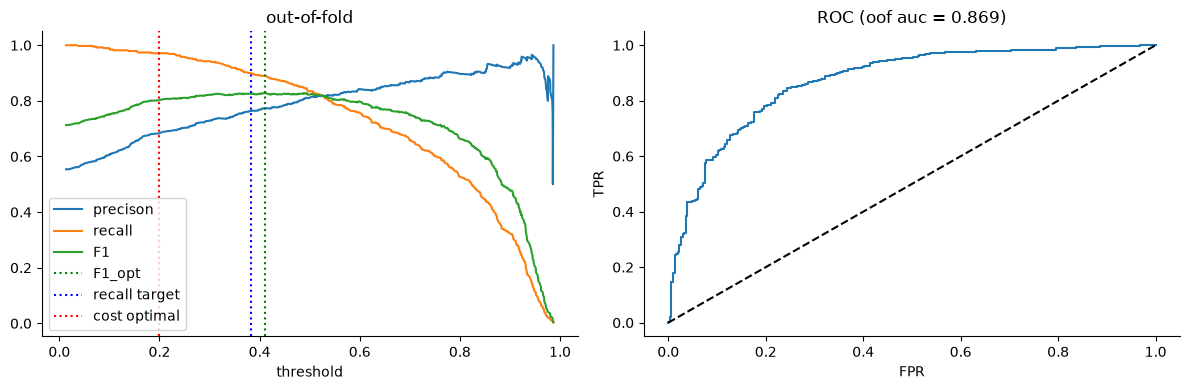

In [79]:
fig, ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(thr,prec[:-1],label='precison')
ax[0].plot(thr,rec[:-1],label='recall')
ax[0].plot(thr,f1s[:-1],label='F1')

for t,lab,col in [(t_f1,'F1_opt','g'),(t_recall,'recall target','b'),
                  (t_cost,'cost optimal','r')]:
    ax[0].axvline(t,ls=':',c=col,label=lab)
ax[0].set_xlabel('threshold'); ax[0].legend(); ax[0].set_title('out-of-fold')

fpr,tpr,_=roc_curve(y_train,p_oof)
ax[1].plot(fpr, tpr); ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR')
ax[1].set_title(f'ROC (oof auc = {roc_auc_score(y_train, p_oof):.3f})')
[a.spines[['top','right']].set_visible(False) for a in fig.axes]
plt.tight_layout()


chose t_cost (0.2) over t_f1 (0.43): a missed diagnosis (fn) is 4x costlier here than an unnecessary follow-up (fp), so the bayes-optimal threshold C_FP/(C_FP+C_FN)=0.2 is the principled pick, not the symmetric f1 peak. at t=0.2, recall≈0.97 vs ~0.83 at t_f1, for only a modest f1 dip (~0.80 vs ~0.84 peak) — the curve shape favors this trade. t_recall (0.405, targeting recall≥0.9) is arbitrary by comparison since 0.9 was a round number, not a cost estimate — t_cost is grounded in an actual cost ratio. this assumes p_oof is calibrated, not just well-ranked — worth a brier/reliability check on the final model .

In [80]:
brier_score_loss(y_train, p_oof)

0.14375540589707203

oof brier = 0.144 vs no-skill baseline 0.247 (dummy prior), brier skill score ( brier version of Rsq)
about 0.42, a real improvement. in-sample brier for base_logreg = 0.137 (skill
about 0.45), so the oof minus in-sample gap is about 0.007, a modest
overfitting gap consistent with the C-vs-gap analysis. both scores rose by
about 0.007 after switching to the explicit 3-flag indicator list (chol and
fbs flags removed), consistent with those flags having carried site-linked
signal. brier does not test calibration, so the threshold of 0.2 still needs a
calibration curve on oof probabilities.

In [81]:
THRESHOLD=float(t_cost)
print('chosen threshold:', round(THRESHOLD, 3))

chosen threshold: 0.2


In [82]:
logit_composite=sm.Logit(y_train,Zc_inf).fit(disp=0)
print(logit_composite.summary2())

                              Results: Logit
Model:                  Logit               Method:              MLE       
Dependent Variable:     target              Pseudo R-squared:    0.374     
Date:                   2026-10-07 18:20    AIC:                 621.7283  
No. Observations:       688                 BIC:                 689.7351  
Df Model:               14                  Log-Likelihood:      -295.86   
Df Residuals:           673                 LL-Null:             -472.90   
Converged:              1.0000              LLR p-value:         5.7690e-67
No. Iterations:         6.0000              Scale:               1.0000    
---------------------------------------------------------------------------
                             Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
---------------------------------------------------------------------------
const                       -1.6205   0.4698 -3.4495 0.0006 -2.5413 -0.6998
age                          0.3065   0.123

In [83]:
(logit_composite.resid_dev**2).sum()

np.float64(591.7282526025738)

logit on Zc_inf (collapsed va-battery flag, current pipeline without chol/fbs
indicators), n = 688, 14 predictors. mcfadden pseudo r2 = 0.374 (adjusted about
0.343), llr p about 6e-67. significant at 0.05: sex, exang, oldpeak, thalach,
age, chol, cp_4 (cp_2 at p = 0.030), with plausible signs. only sex, exang,
oldpeak and thalach. not
significant: trestbps, fbs, restecg, cp_3, and the va-battery flag (or about
1.57, p = 0.23, wide ci), so the data is uninformative about that flag, not
evidence of no effect. judge cp and restecg with joint lr tests, not per
level. coefficients are in-sample associations from an unpenalized fit with
imputed values treated as observed, not confirmed physiological effects.
logo:

In [84]:
ci=logit_composite.conf_int()
ci

,0,1
const,-2.541301,-0.699780
age,0.064298,0.548763
trestbps,-0.208752,0.226139
chol,0.037665,0.455705
thalach,-0.671046,-0.184812
oldpeak,0.240641,0.718132
sex,0.860707,1.933489
fbs,-0.433205,0.770180
cp_2.0,-2.013024,-0.102179
cp_3.0,-1.124760,0.632033


In [85]:
odds=pd.DataFrame({
    'coef':logit_composite.params,
    'OR':np.exp(logit_composite.params),
    'OR_lo':np.exp(ci[0]),
    'OR_hi':np.exp(ci[1]),
    'p': logit_composite.pvalues
}).drop(index='const').sort_values('OR',ascending=False)
odds.round(3)

,coef,OR,OR_lo,OR_hi,p
sex,1.397,4.043,2.365,6.914,0.000
exang_1.0,1.111,3.037,1.846,4.996,0.000
cp_4.0,0.997,2.710,1.145,6.415,0.023
oldpeak,0.479,1.615,1.272,2.051,0.000
missingindicator_va_battery,0.454,1.574,0.749,3.307,0.231
restecg_1.0,0.341,1.407,0.795,2.489,0.241
age,0.307,1.359,1.066,1.731,0.013
chol,0.247,1.280,1.038,1.577,0.021
restecg_2.0,0.174,1.190,0.708,2.003,0.511
fbs,0.168,1.184,0.648,2.160,0.583


converted logit coefs to ORs (exp(coef)) for interpretability. ORs are conditional on the other columns in the model. numeric columns are standardised, so their ORs are per 1 SD. binary and one-hot columns are per unit, relative to the dropped reference level (cp = 1, restecg = 0). a CI crossing 1 is the same check as p > 0.05. unpenalised fit, in-sample, imputed values treated as observed.

strongest and tightest: sex (OR 4.04, CI 2.37 to 6.91) and exang (OR 3.04, CI 1.85 to 5.00), both p < 0.001. oldpeak (OR 1.62 per SD, CI 1.27 to 2.05) and thalach (OR 0.65 per SD, protective, CI 0.51 to 0.83) are smaller but well estimated. these four are the only effects that survive a bonferroni threshold for 14 tests (0.05/14, about 0.0036).

weaker, nominal significance only: age (1.36 per SD, p = 0.013), chol (1.28 per SD, p = 0.021), cp_4 (2.71, CI 1.15 to 6.42) and cp_2 (0.35, CI 0.13 to 0.90). not significant: cp_3, both restecg levels, fbs, trestbps.

cp pattern: relative to typical angina, asymptomatic chest pain (cp_4) has higher odds and atypical angina (cp_2) has lower odds. cp_2 and cp_3 intervals are wide (about 6x span) because the groups are small. cp codes are not ordered by risk, so one-hot is the right encoding.

missingindicator_va_battery: OR 1.57, CI 0.75 to 3.31, p = 0.23. the data is uninformative about this flag. no evidence of an effect, not evidence of no effect.

caveat on sex: site is not in the model, and the sites differ strongly in sex mix and prevalence, so sex may partly proxy site. the sex OR rose from about 3.6 to 4.0 after the chol and fbs indicators were dropped, consistent with this but untested.



` *consistent with this*.`

site-adjusted refit (inference only; cleveland reference, va-battery flag retired): sex OR moved from 4.04 [2.37, 6.91] to 3.62 [2.05, 6.41], a 10.4% change, right at the conventional 10% change-in-estimate cutoff (7.8% on the log-odds scale), so site confounding is at most marginal and sex is not mainly a proxy for site. only switzerland picked up a large site term (OR 12.5); the within-site estimate rests mostly on cleveland and hungary, which hold 133 of the 145 women.
.

summ: exang, oldpeak and thalach are the clearest effects. report sex with the site-confound caveat. treat age, chol and the cp levels as suggestive, not confirmed.

In [86]:
#robust SEs mispecification not heteroscedasticity fix
logit_hc3=sm.Logit(y_train,Zc_inf).fit(cov_type='HC3')
pd.DataFrame({
    'se model':logit_composite.bse, 'se robust':logit_hc3.bse,
    'ratio':(logit_hc3.bse/logit_composite.bse)
}).round(3)


Optimization terminated successfully.
         Current function value: 0.430035
         Iterations 6


,se model,se robust,ratio
const,0.470,0.511,1.087
age,0.124,0.118,0.958
trestbps,0.111,0.123,1.108
chol,0.107,0.107,0.999
thalach,0.124,0.127,1.022
oldpeak,0.122,0.119,0.978
sex,0.274,0.268,0.978
fbs,0.307,0.330,1.075
cp_2.0,0.487,0.522,1.071
cp_3.0,0.448,0.499,1.114


ran HC3 sandwich SEs to check whether the model-based p-values and CIs are trustworthy. naive MLE SEs assume the bernoulli model is exactly right, and the site heterogeneity found elsewhere (logo gap) made that worth stress-testing. for a 0/1 outcome this probes misspecification of the mean model, not heteroscedasticity in the ols sense.

robust/model SE ratios fall between 0.958 and 1.114 for every coefficient, under about 11% movement. no coefficient changes significance at 0.05. the closest to the edge are cp_2 and cp_4 (p about 0.04 under HC3, was 0.03 and 0.02), and neither passes a bonferroni threshold anyway. sex, exang, oldpeak and thalach remain significant at that threshold. no sign that the model-based SEs are wrong for independent rows.

In [87]:
logit_cluster=sm.Logit(y_train, Zc_inf).fit(cov_type='cluster', cov_kwds={'groups': g_train}) 
pd.DataFrame({
    'se model':logit_composite.bse, 'se robust':logit_cluster.bse,
    'ratio':(logit_cluster.bse/logit_composite.bse)
}).round(3)

Optimization terminated successfully.
         Current function value: 0.430035
         Iterations 6


,se model,se robust,ratio
const,0.470,0.781,1.662
age,0.124,0.074,0.598
trestbps,0.111,0.091,0.819
chol,0.107,0.053,0.494
thalach,0.124,0.173,1.392
oldpeak,0.122,0.199,1.630
sex,0.274,0.254,0.927
fbs,0.307,0.406,1.323
cp_2.0,0.487,0.933,1.914
cp_3.0,0.448,0.472,1.054


ran cluster-robust SEs (grouped by site, G = 4) to test the within-site correlation that HC3 cannot address. ratios (cluster-robust / model-based) range from 0.49 (chol) to 1.91 (cp_2), in both directions with no consistent pattern (age shrinks about 40%, cp_2 grows about 91%, exang about 66%, oldpeak about 63%).

not real signal: with G = 4 the meat matrix has rank at most 3 (cluster score sums add to zero at the MLE) against 15 parameters, so the robust covariance is rank-deficient and individual SEs and joint tests are unreliable. the ratios are noisy draws, not corrections.

negative result: this check cannot decide either way on whether the model-based SEs are valid under within-site correlation. do not repeat cluster SEs on this dataset. logo cv answers a different question (prediction on a held-out site), not inference. for coefficient inference, the practical test is a site covariate (3 dummies) in the logit.

In [90]:
big=pd.DataFrame({'coef':logit_composite.params,'se':logit_composite.bse})
flag=big[(big.coef.abs()>8) | (big.se.abs()>8 )]
print('separation suspects:' if len(flag) else 'no sepration detected')
flag.round(2)

no sepration detected


,coef,se


In [88]:
## sex vs site: refit with site as a covariate (inference only)

In [89]:
site_d=pd.get_dummies(g_train,prefix='site',drop_first=True,dtype=float)  #cleveland is the reference
assert site_d.index.equals(X_train.index)
site_d.columns.tolist()

['site_hungary', 'site_switzerland', 'site_va']

In [91]:
pd.crosstab(g_train,Zc_inf['missingindicator_va_battery'])  #where the flag fires

Zc_site=pd.concat([Zc_inf.drop(columns='missingindicator_va_battery'),site_d],axis=1)
print(Zc_inf.shape,Zc_site.shape)

(688, 15) (688, 17)


In [92]:
r,k=np.linalg.matrix_rank(Zc_site),Zc_site.shape[1]
assert r==k #site dummies identifiable next to the other predictors

In [93]:
logit_site=sm.Logit(y_train,Zc_site).fit(disp=0)
assert logit_site.mle_retvals['converged']

big_site=pd.DataFrame({'coef':logit_site.params,'se':logit_site.bse})
flag_site=big_site[(big_site.coef.abs()>8) | (big_site.se.abs()>8)]
print('separation suspects:' if len(flag_site) else 'no sepration detected')
flag_site.round(2)


no sepration detected


,coef,se


In [94]:
ci_site=logit_site.conf_int()
odds_site=pd.DataFrame({
    'coef':logit_site.params,
    'OR':np.exp(logit_site.params),
    'OR_lo':np.exp(ci_site[0]),
    'OR_hi':np.exp(ci_site[1]),
    'p': logit_site.pvalues
}).drop(index='const')

pd.DataFrame({'without site':odds.loc['sex'],'with site':odds_site.loc['sex']}).T.round(3)


,coef,OR,OR_lo,OR_hi,p
without site,1.397,4.043,2.365,6.914,0.0
with site,1.288,3.624,2.050,6.405,0.0


In [95]:
odds_site.filter(like='site_',axis=0).round(3)


,coef,OR,OR_lo,OR_hi,p
site_hungary,-0.012,0.988,0.519,1.880,0.970
site_switzerland,2.523,12.470,4.561,34.094,0.000
site_va,0.440,1.552,0.767,3.141,0.221


flagged on both: 20 of 688


,age,trestbps,chol,thalach,oldpeak,sex,fbs,cp,restecg,exang,target
183,59.0,178.0,270.0,145.0,4.2,1.0,0.0,1.0,2.0,0.0,0
558,46.0,140.0,272.0,175.0,2.0,1.0,1.0,1.0,0.0,0.0,1
691,62.0,120.0,NaN,134.0,-0.8,1.0,NaN,1.0,2.0,0.0,1
595,58.0,180.0,393.0,110.0,1.0,0.0,0.0,2.0,0.0,1.0,1
811,40.0,106.0,240.0,80.0,0.0,1.0,0.0,3.0,0.0,1.0,0
853,68.0,NaN,181.0,NaN,NaN,1.0,1.0,1.0,1.0,NaN,0
780,51.0,NaN,218.0,NaN,NaN,1.0,1.0,4.0,2.0,NaN,0
387,46.0,180.0,280.0,120.0,0.0,1.0,0.0,4.0,1.0,0.0,0
819,63.0,130.0,NaN,160.0,3.0,1.0,1.0,3.0,1.0,0.0,0
889,57.0,180.0,285.0,120.0,0.8,1.0,1.0,2.0,1.0,0.0,1


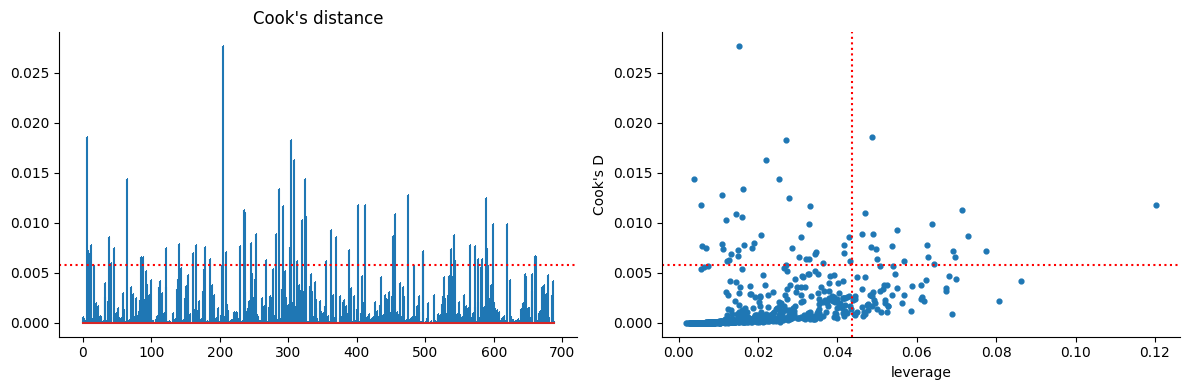

In [ ]:
#influence , lev , cook's distance
glm_fit=sm.GLM(y_train,Zc_inf,family=sm.families.Binomial()).fit()
infl=glm_fit.get_influence()
cooks_dis=infl.cooks_distance[0]
hat=infl.hat_matrix_diag

n,p=Zc_inf.shape
cook_cut,hat_cut=4/n,2 *(p/n)

fig,ax=plt.subplots(1,2, figsize=(12,4))
ax[0].stem(np.arange(n),cooks_dis,markerfmt=',')
ax[0].axhline(cook_cut,c='r',ls=':')
ax[0].set_title("Cook's distance")
ax[1].scatter(hat, cooks_dis, s=12)
ax[1].axvline(hat_cut, color='r', ls=':'); ax[1].axhline(cook_cut, color='r', ls=':')
ax[1].set_xlabel('leverage'); ax[1].set_ylabel("Cook's D")
plt.tight_layout()

flag=np.where((cooks_dis>cook_cut)& (hat > hat_cut))[0]
print(f'flagged on both: {len(flag)} of {n}')
# X_train.iloc[flag].head(19)
[a.spines[['top','right']].set_visible(False) for a in fig.axes]
pd.concat([X_train.iloc[flag],y_train.iloc[flag]],axis=1)



left (cook's D stem, by row index): most stems sit near zero. a handful cross the red dotted line (cook_cut = 4/n, about 0.0058), the tallest at about 0.028. spikes are scattered across the whole index range with no block. the x-axis is just row position after the train split, so it carries no meaning.

right (leverage vs cook's D): four quadrants, split at hat_cut = 2p/n (about 0.044, twice the average leverage of p/n) and cook_cut.
- bottom-left: typical rows, most of the mass.
- top-left: high cook's D, low leverage. ordinary predictors but a badly fitted outcome. the single tallest spike falls here.
- bottom-right: high leverage, low cook's D. unusual predictor profile that the model still fits well.
- top-right: high leverage and high cook's D. unusual predictors with a real pull on the coefficients. this is what flag = np.where((cooks_dis > cook_cut) & (hat > hat_cut)) selects, the intersection and not either alone. 20 of 688 rows (about 2.9%).

what the flagged rows are: 7 of 20 have NaNs. four (853, 780, 792, 916) have the whole exercise block missing, so they carry the va-battery flag, and all four are target = 0 while that flag's coefficient is positive. rows 691, 819 and 615 are missing chol, and 691 and 615 also fbs. the remaining rows hold extreme but plausible values (chol 564, oldpeak 4.2 and -2.6, thalach 80, trestbps 180). the table shows raw values, but the model saw median-filled ones plus the flag. missing-data rows are somewhat over-represented among flagged rows (exercise block 4 of 20 against about 7% overall), but chol-missing rows are not (3 of 20 against about 22%). weak evidence, not a confirmed pattern.

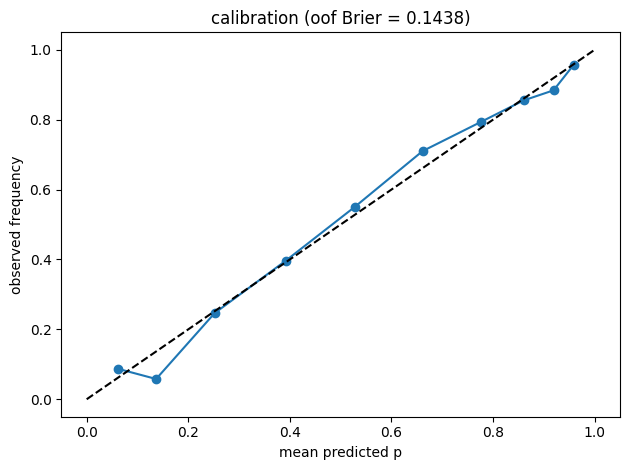

In [ ]:
frac_pos, mean_pred=calibration_curve(y_train,p_oof,n_bins=10,strategy='quantile')
plt.plot(mean_pred, frac_pos, 'o-')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('mean predicted p'); plt.ylabel('observed frequency')
plt.title(f'calibration (oof Brier = {brier_score_loss(y_train, p_oof):.4f})')
plt.tight_layout()

reliability diagram (oof, brier = 0.1438, 10 quantile bins of about 69 rows). points track the diagonal closely across the whole range with no systematic drift. gaps are within about 1 SE of binomial noise  except one low bin , about what chance gives across 10 bins. the two lowest bins disagree in direction, and the top bin is slightly over-confident (0.92 predicted vs 0.885 observed, within noise), so no reliable over-confidence at the extremes. mild under-confidence at 0.66 (observed 0.71) is also within noise.

the cost threshold t = 0.2 falls between two bins (0.135 and 0.25), so the plot cannot resolve calibration exactly there. calibration slope and intercept on the oof probabilities would test it with all rows. this supports using the probabilities for the cost-based threshold, within these four hospitals. random-fold oof only, so calibration on a new site is untested and base-rate differences (switzerland about 93% positive) will make it worse there.

In [ ]:
p_test=final_model.predict_proba(X_test)[:,1]
rows.append(evaluate(y_test,p_test,thresh=0.5,name='FInal model 0.5 thresh',split='test'))
rows.append(evaluate(y_test,p_test,thresh=THRESHOLD,name=f'final model @ {THRESHOLD:.2f}',split='test'))
rows.append(evaluate(y_train, p_oof, thresh=0.5, name='final model (OOF) 0.5 thresh',split='oof'))
rows.append(evaluate(y_train, p_oof, thresh=THRESHOLD, name=f'final model (OOF) @ {THRESHOLD:.2f}',split='oof'))

pd.DataFrame(rows)


,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,avg_precision,brier
0,dummy prior,train,0.5,0.554,0.554,1.000,0.713,0.500,0.554,0.247
1,dummy most_frequent,train,0.5,0.554,0.554,1.000,0.713,0.500,0.554,0.446
2,dummy stratified,train,0.5,0.510,0.558,0.559,0.558,0.504,0.556,0.490
3,base log reg,train,0.5,0.815,0.819,0.856,0.837,0.881,0.888,0.137
4,FInal model 0.5 thresh,test,0.5,0.817,0.820,0.858,0.838,0.891,0.891,0.131
5,final model @ 0.20,test,0.2,0.743,0.687,0.984,0.809,0.891,0.891,0.131
6,final model (OOF) 0.5 thresh,oof,0.5,0.801,0.811,0.835,0.823,0.869,0.873,0.144
7,final model (OOF) @ 0.20,oof,0.2,0.735,0.684,0.971,0.803,0.869,0.873,0.144


final comparison (dummy baselines and in-sample base logreg on train, tuned model on oof and test, at 0.5 and at the cost-based 0.2). baselines are at auc 0.50 as expected. the final model clears every baseline by a wide margin on both oof and test. threshold tradeoff (0.5 to 0.2): recall 0.86 to 0.98 and precision 0.82 to 0.69 on test, 0.84 to 0.97 and 0.81 to 0.68 on oof. consistent across oof and test. t = 0.2 came from the cost ratio (4 to 1), not tuned on test, so the test row is a clean check on unseen patients from the same four sites.

test vs oof: test is slightly better (auc 0.891 vs 0.869, ap 0.891 vs 0.873, brier 0.131 vs 0.144), but with about 230 test rows the auc se is about 0.02 and the brier se about 0.013, so each gap is about 1 se. the final model is also fitted on 100% of train versus about 80% inside oof folds. no unusual outperformance. report test and nested cv together (test 0.891, nested 0.868) as within-site estimates. cross-site performance comes from logo and is lower (rerun on current pipeline before quoting). optional: compare site mix of x_test with train.

In [ ]:
g_test = groups.loc[X_test.index]
pd.concat([g_train.value_counts(normalize=True).rename('train'),
           g_test.value_counts(normalize=True).rename('test')], axis=1)


,train,test
site,,
cleveland,0.331395,0.326087
hungary,0.313953,0.334783
va,0.226744,0.186957
switzerland,0.127907,0.152174


checked site composition of x_test against train. test shares are cleveland 32.6% (train 33.1%), hungary 33.5% (31.4%), va 18.7% (22.7%), switzerland 15.2% (12.8%). a chi-square on the test counts (75, 77, 43, 35 of 230) gives about 3.0 on 3 df, p about 0.4, so the mix is consistent with a random split stratified by target only. no evidence it explains test beating oof, and the direction of any effect on pooled auc is not established, since prevalence differs a lot by site.

more likely explanation is sampling variance. the 230-row test set has an auc se of about 0.017 to 0.02 (outer cv folds of about 138 rows had std 0.022), so the gap of 0.022 (test 0.891 vs oof 0.869) is about 1.3 se. the final model is also fitted on all of train, versus about 80% inside oof folds.

headline: report both, test 0.891 and nested cv 0.868, as within-site estimates that agree within noise. the oof/nested estimate rests on 688 rows against 230 for test, so it is the better-determined of the two. cross-site performance comes from logo (rerun on the current pipeline before quoting).

In [ ]:
y_pred=(p_test>=THRESHOLD).astype(int)
print(classification_report(y_test,y_pred,digits=3))

              precision    recall  f1-score   support

           0      0.958     0.447     0.609       103
           1      0.687     0.984     0.809       127

    accuracy                          0.743       230
   macro avg      0.823     0.715     0.709       230
weighted avg      0.808     0.743     0.720       230



classification report at the cost-based threshold t = 0.2 on the test set (n = 230, 127 positive, 103 negative). rebuilt confusion matrix: tp 125, fn 2, tn 46, fp 57.

positives: recall 0.984, precision 0.687. negatives: recall (specificity) 0.447, precision (npv) 0.958. accuracy 0.743, macro f1 0.709.

the report looks poor because the threshold was set for unequal costs, and accuracy and macro averages treat both errors as equally costly. the same model at 0.5 scores accuracy 0.817 on this test set. the low specificity is the direct price of the low cutoff: 57 of 103 healthy patients are flagged (182 of 230 flagged overall, 79%), and in return only 2 positives are missed.

cost view, (fp + 4 * fn) / n with c_fn = 4 * c_fp: t = 0.2 gives 0.283 per patient, t = 0.5 gives about 0.417 (counts rebuilt from its precision and recall), flagging everyone gives 0.448. so 0.2 costs about a third less than 0.5.

limits: the case for 0.2 rests on the assumed 4 to 1 ratio. 0.5 becomes cheaper if the true ratio is below about 2.1. if each flag triggers a costly follow-up that is not in c_fp, the real false alarm cost is higher than assumed. recall rests on only 2 misses (interval roughly 0.94 to 1.0). within-site estimate only, recall at 0.2 will likely be lower on a new hospital.


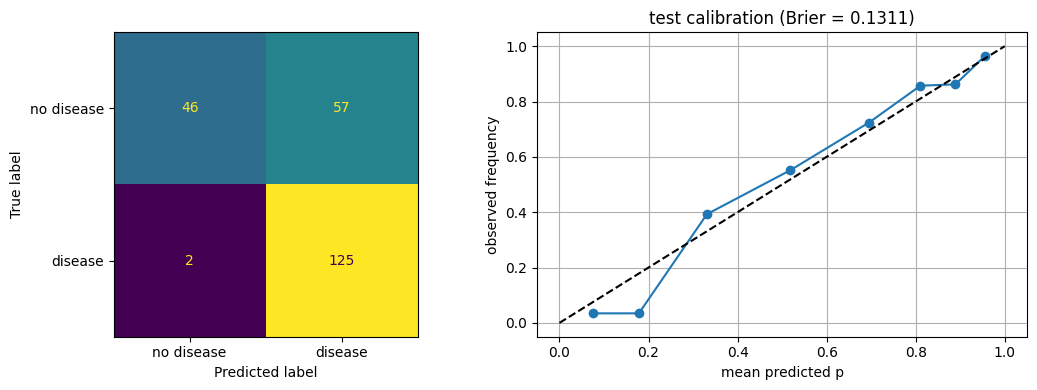

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(11,4))
ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred),
                       display_labels=['no disease','disease']).plot(ax=ax[0],colorbar=False)

frac_pos, mean_pred=calibration_curve(y_test,p_test,n_bins=8,strategy='quantile')
ax[1].plot(mean_pred, frac_pos, 'o-')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_xlabel('mean predicted p'); ax[1].set_ylabel('observed frequency')
plt.title(f'test calibration (Brier = {brier_score_loss(y_test,p_test):.4f})')
plt.tight_layout();ax[1].grid(True)

per-class breakdown at t_cost = 0.2 (test, n = 230): confusion matrix tn 46, fp 57, fn 2, tp 125. disease recall 0.984 (2 of 127 missed), precision 0.687. no-disease recall (specificity) 0.447, so 57 of 103 healthy patients are flagged. this is the direct cost of the 4 to 1 fn to fp ratio. macro avg (recall 0.715, precision 0.823, f1 0.709) hides this asymmetry. report per-class numbers, not the average, to a non-technical audience.

test calibration (brier 0.1311, matches the summary table), 8 quantile bins of about 29 rows each. middle and upper bins (predicted 0.33 and above) sit within about 1 se of the diagonal. the two lowest bins (predicted 0.07 and 0.18) have observed frequency about 0.03, below the diagonal. the bin at 0.18 is about 2 se off. the same direction appeared in the oof curve (0.135 predicted, 0.055 observed), so the model probably over-predicts risk in the 0.1 to 0.2 range. at t = 0.2 this means a few patients are flagged whose true risk is below the 0.2 cost cutoff, a slightly conservative threshold. effect on cost is small because the cost curve is flat there.

not tuned on test. any adjustment (calibration slope and intercept on oof, or a calibrator fitted inside the cv) should use training data only. calibration is acceptable in the range that governs most decisions (0.3 and above), within these four hospitals. each bin has only about 29 rows, so the low range cannot be confirmed from test alone.

Background dataset has 688 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=688 when initializing the masker.


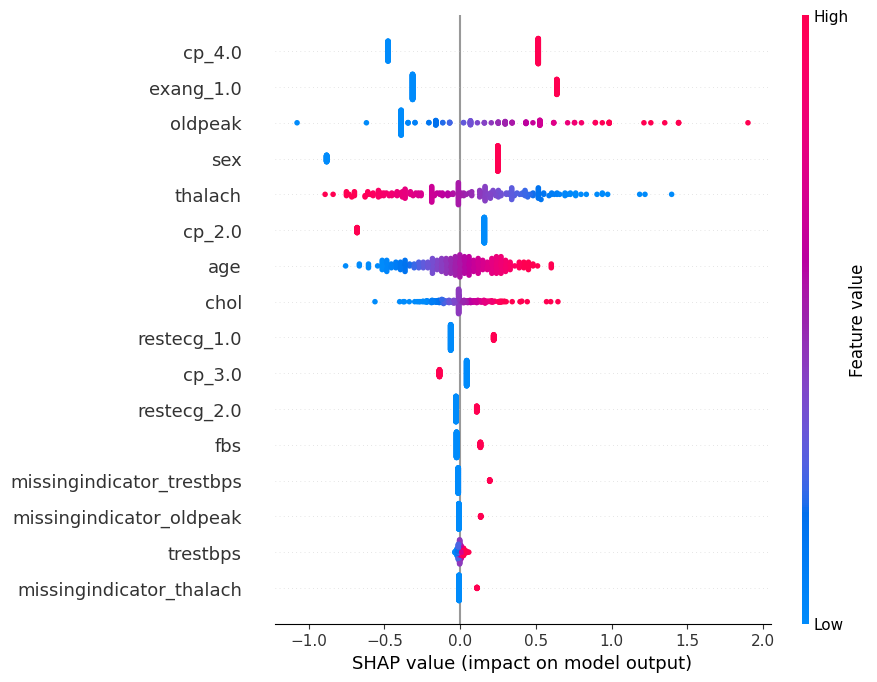

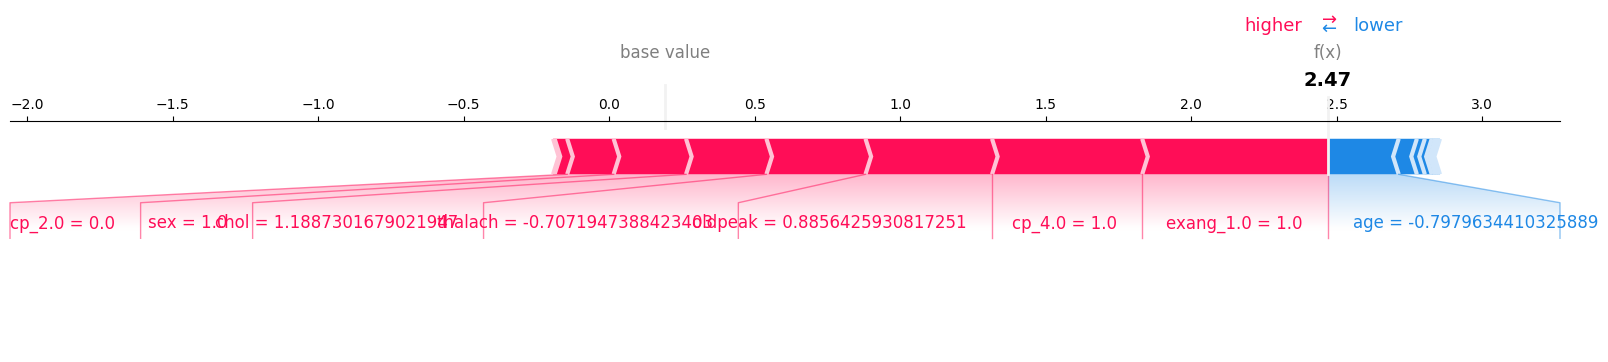

In [ ]:
pre= final_model.named_steps['pre']
clf= final_model.named_steps['clf']
names = [n.split('__', 1)[1] for n in pre.get_feature_names_out()]
Z_tr = pd.DataFrame(pre.transform(X_train), columns=names, index=X_train.index)
Z_te = pd.DataFrame(pre.transform(X_test),  columns=names, index=X_test.index)
explainer = shap.LinearExplainer(clf, Z_tr)   # background = train
sv = explainer(Z_te)  


shap.plots.beeswarm(sv, max_display=20)

i = 0                                         # position of the test row to explain
shap.plots.force(sv[i], matplotlib=True)

shap on the final model( logistic regression step of the pipeline, preprocessor output as input). background is the train matrix, explained rows are the test set. units are log-odds. for a linear model, phi_ij = beta_j * (z_ij - zbar_j), where beta_j is the coefficient, z_ij the patient's value and zbar_j the train mean of that column. base value is the mean train log-odds (about 0.18, probability about 0.55) and base plus the sum of phi equals the patient's log-odds. these are attributions of the model, not causal effects.

beeswarm (each dot is a test patient, x is the push on risk, colour is the column value, columns ordered by mean absolute phi). strongest: cp_4, exang, oldpeak, sex, thalach, then cp_2, age, chol. weak or near zero: restecg, cp_3, fbs, trestbps and the three missingindicator columns. this matches the logit ranking (trestbps p = 0.94, flags not significant).

binary columns (cp_4, exang, sex, cp_2, restecg, fbs, flags) show two tight clusters. the gap between them is about the (shrunken) coefficient, roughly 1.0 for cp_4 and exang, 1.1 for sex. the cluster positions depend on prevalence, since phi = beta * (z - zbar). male patients (about 79% of rows) sit at about +0.25 and the rarer female patients at about -0.88. so a large bar on a rare category means unusual, not necessarily more important.

numeric columns: high oldpeak and low thalach push risk up (thalach is protective). oldpeak has the widest spread and a long right tail (up to about +1.9), driven by a few very high values. age and chol have smaller, smoother spreads.

the three exercise-block missing flags are near-duplicates, so shap divides their combined effect among them. each is small (about +0.1 to +0.2 when flagged). read their sum, not individual bars. sex may partly proxy site, since site is not in the model.

force plot, one test patient: f(x) = 2.47 log-odds (probability about 0.92) against a base of about 0.18. pushing risk up: cp_4 = 1, exang = 1, sex = 1, high chol, high oldpeak, low thalach, cp_2 = 0 (below the column average, so zero lifts risk). pushing down: age (0.8 sd below average, with a positive coefficient). the cost cutoff 0.2 is -1.39 on this axis, so no single bar could change this patient's flag. numeric values in the labels are in sd units. labels overlap because they carry full-precision floats and the plot does not space neighbouring labels, so round the values or use the waterfall plot.

In [ ]:
# def lrt(restricted, full, name=''):
#     """Likelihood-ratio test.  `restricted` must be `full` with coefficients
#     dropped, fit on the SAME rows.  Requires UNPENALISED MLE fits."""
#     assert restricted.nobs == full.nobs, 'models fit on different rows'
#     stat = 2 * (full.llf - restricted.llf)
#     df = int(round(full.df_model - restricted.df_model))
#     assert df > 0, 'models are not nested (or are identical)'
#     return {'test': name,
#             'll_restricted': round(restricted.llf, 3),
#             'll_full': round(full.llf, 3),
#             'LR_stat': round(stat, 4),
#             'df': df,
#             'p_value': stats.chi2.sf(stat, df)}

# def fit_logit(cols, design=Zc_inf):
#     """Refit on a column subset of the inference design, always keeping const."""
#     cols = ['const'] + [c for c in cols if c != 'const']
#     return sm.Logit(y_train, design[cols]).fit(disp=0)

In [ ]:
# all_cols = [c for c in Zc_inf.columns if c != 'const']
# miss_block = [c for c in all_cols if c.startswith('missingindicator_')]
# cp_block = [c for c in all_cols if c.startswith('cp_')]
 
# print('missingness block :', miss_block)
# print('cp block          :', cp_block)
# print('all columns       :', all_cols)
 

In [ ]:
# lr_rows = [
#     lrt(fit_logit([c for c in all_cols if c not in miss_block]),
#         logit_composite, 'missingness indicators (joint)'),
#     lrt(fit_logit([c for c in all_cols if c not in cp_block]),
#         logit_composite, 'cp / chest pain type (joint)'),
# ]
# lr_rows

In [ ]:
# print(f'LR chi2 = {logit_composite.llr:.2f}  df = {logit_composite.df_model:.0f}  '
#       f'p = {logit_composite.llr_pvalue:.3g}')
